# Supernova distances and redshifts (Part 2)

In [1]:
import numpy as np
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

In [2]:
import sys
sys.path.append(r"C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks")
from Utilities import plot_settings
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Raw Data')

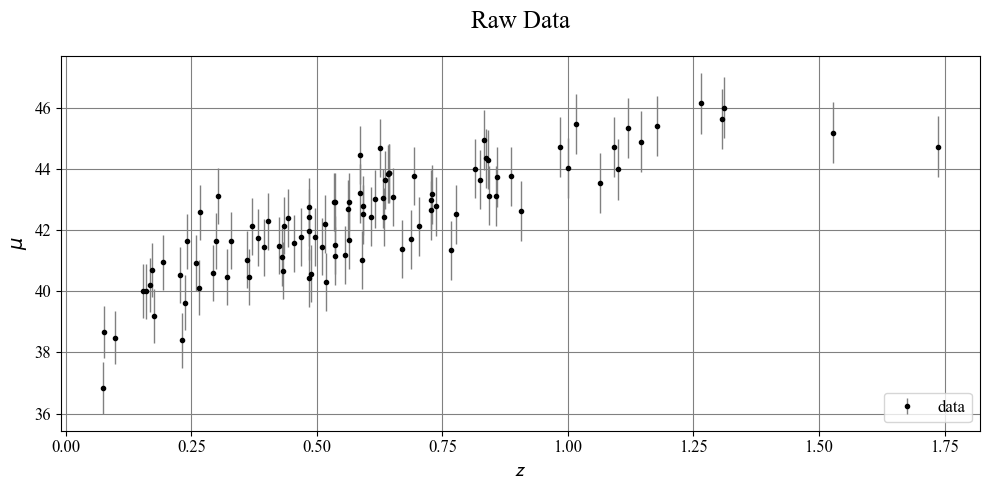

In [3]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel(r"$\mathcal{z}$")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title('Raw Data')

In [5]:
import random
random_seed = 54

np.random.seed(random_seed)
random.seed(random_seed)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
z_train, z_test, mu_train, mu_test, dmu_train, dmu_test = train_test_split(z_sample, mu_sample, dmu, test_size=0.2, random_state=42)

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the kernels submodule of sklearn.gaussian_process
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern, RationalQuadratic
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error

In [14]:
Base_Kernels = [
    RBF(length_scale=0.001, length_scale_bounds=(1e-8, 1e8)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1)),
    Matern(length_scale=0.001, length_scale_bounds=(1e-8, 1e8)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1)),
    RationalQuadratic(length_scale=0.001) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-10, 1e+1))
]

In [15]:
# Cross-validation strategy
custom_cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Search grid
param_grid = {
    'kernel__k1__length_scale': np.logspace(-3, -1, 5),
    'kernel__k2__noise_level': np.logspace(-1, 2, 5)
}

# Track best model manually
best_score = -np.inf
best_model = None
best_kernel = None

# Grid search over kernels
for kernel in Base_Kernels:
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0, normalize_y=True)
    grid = GridSearchCV(gpr, param_grid, cv=custom_cv, scoring='neg_mean_squared_error')
    grid.fit(z_train.reshape(-1, 1), mu_train)
    
    score = grid.best_score_
    print(f"Kernel: {kernel}")
    print(f"Best score (neg MSE): {score:.4f}")
    print(f"Best params: {grid.best_params_}\n")

    if score > best_score:
        best_score = score
        best_model = grid.best_estimator_
        best_kernel = kernel

# After loop: evaluate best model on test set
y_test_pred = best_model.predict(z_test.reshape(-1, 1))
test_mse = mean_squared_error(mu_test, y_test_pred)

print(f"Best kernel: {best_model.kernel_}")
print(f"Test MSE: {test_mse:.3f}")

c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.


Kernel: RBF(length_scale=0.001) + WhiteKernel(noise_level=1)
Best score (neg MSE): -0.9613
Best params: {'kernel__k1__length_scale': np.float64(0.1), 'kernel__k2__noise_level': np.float64(3.1622776601683795)}



c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.


Kernel: Matern(length_scale=0.001, nu=1.5) + WhiteKernel(noise_level=1)
Best score (neg MSE): -0.9731
Best params: {'kernel__k1__length_scale': np.float64(0.01), 'kernel__k2__noise_level': np.float64(0.1)}



c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warning

Kernel: RationalQuadratic(alpha=1, length_scale=0.001) + WhiteKernel(noise_level=1)
Best score (neg MSE): -0.9629
Best params: {'kernel__k1__length_scale': np.float64(0.03162277660168379), 'kernel__k2__noise_level': np.float64(0.5623413251903491)}

Best kernel: RBF(length_scale=0.459) + WhiteKernel(noise_level=0.247)
Test MSE: 0.866


In [18]:
best_model.fit(z_train.reshape(-1,1), mu_train)

,kernel,RBF(length_sc...se_level=3.16)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,RBF(length_scale=0.1)
,kernel__k2,WhiteKernel(noise_level=3.16)
,kernel__k1__length_scale,np.float64(0.1)


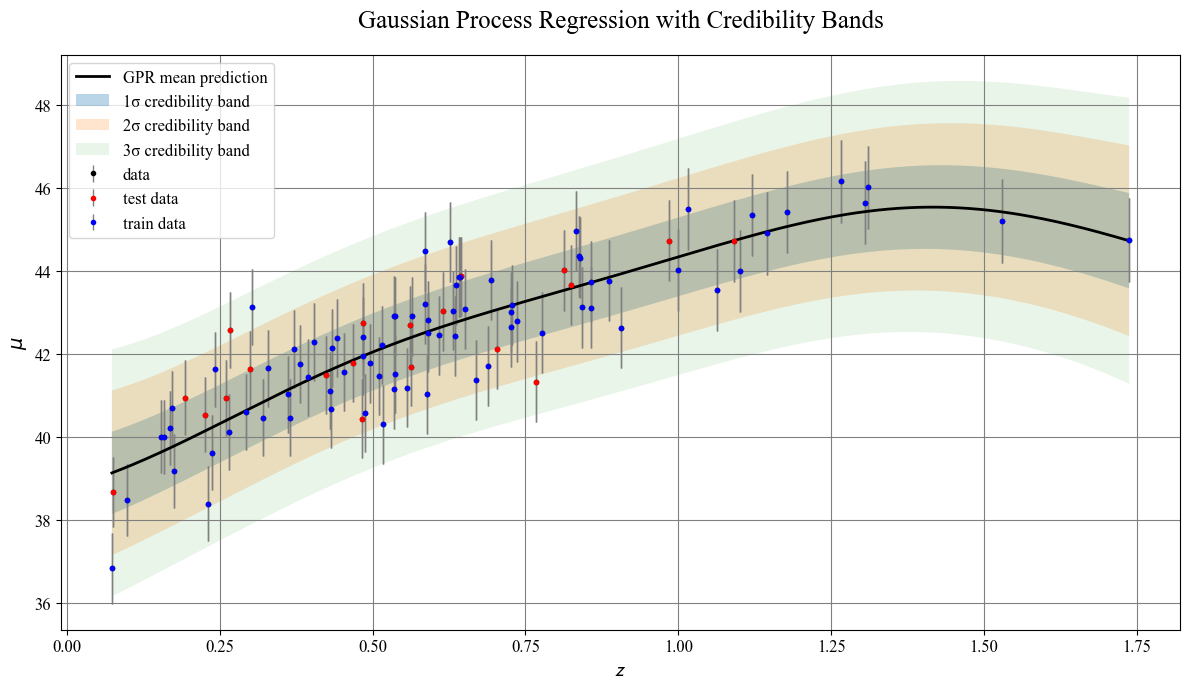

In [19]:
X = z_train.reshape(-1, 1)
y = mu_train.reshape(-1, 1)

gpr = best_model

# Predict over a dense grid
x_fit = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_mean, y_std = gpr.predict(x_fit, return_std=True)

# Credibility bands: ±1σ, ±2σ, ±3σ
bands = {
    '1σ': (y_mean.ravel() - 1*y_std, y_mean.ravel() + 1*y_std, 0.3),
    '2σ': (y_mean.ravel() - 2*y_std, y_mean.ravel() + 2*y_std, 0.2),
    '3σ': (y_mean.ravel() - 3*y_std, y_mean.ravel() + 3*y_std, 0.1),
}

# Plot
plt.figure(figsize=(12, 7))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.errorbar(z_test, mu_test, dmu_test, fmt='.r', ecolor='gray', lw=1, label='test data')
plt.errorbar(z_train, mu_train, dmu_train, fmt='.b', ecolor='gray', lw=1, label='train data')

plt.plot(x_fit, y_mean, 'k-', label='GPR mean prediction')

# Fill credibility regions
for label, (lower, upper, alpha) in bands.items():
    plt.fill_between(x_fit.ravel(), lower, upper, alpha=alpha, label=f'{label} credibility band')

plt.xlabel(r"$\mathcal{z}$")
plt.ylabel(r"$\mu$")
plt.title("Gaussian Process Regression with Credibility Bands")
plt.legend()
plt.grid(True)
plt.show()

### Error Distribution

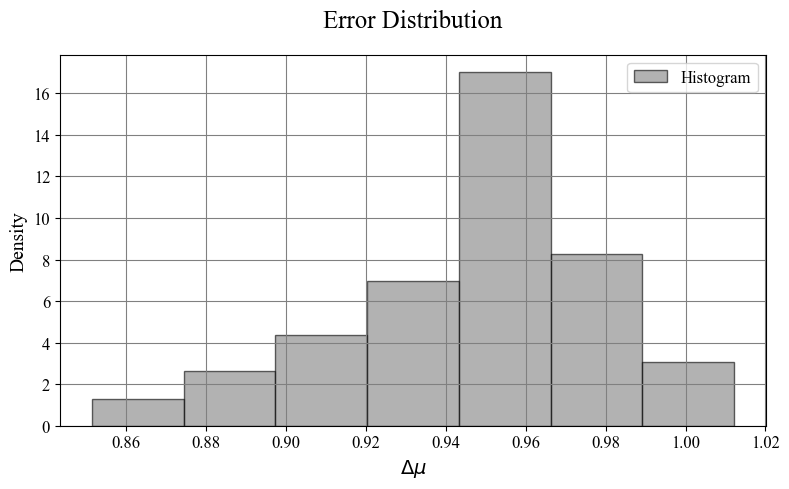

In [109]:
plt.figure(figsize=(8,5))
plt.hist(dmu, bins='scott', density=True, color='gray', edgecolor='black', alpha=0.6, label='Histogram')
plt.title('Error Distribution')
plt.xlabel(r'$\Delta \mu$')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
from scipy import stats

mu, sigma = np.mean(dmu), np.std(dmu)
ks_stat, ks_p = stats.kstest(dmu, 'norm', args=(mu, sigma))
print('Threshold : 5%')
print(f"Kolmogorov–Smirnov Test:\nStatistic = {ks_stat:.4f}, p-value = {ks_p*100:.4} %")
print(f'Gaussian distribution moments: mu = {mu:.2}, sigma = {sigma:.2}')


Threshold : 5%
Kolmogorov–Smirnov Test:
Statistic = 0.1088, p-value = 17.43 %
Gaussian distribution moments: mu = 0.95, sigma = 0.032


So I have not strong enough evidence to reject the null hypothesis ('Errors distribution is normal').\
This means that I am facing a regression problem with negligible (absent) errors on the independent variable, and not negligible errors on the dependent variable, wchich are drawn from a gaussian distribution with known $\mu$ and $\sigma$ so I can write the posterior as 


$$ \mathcal{l} = \sum_{i=1}^{N} \log p(y_i|x_i, \vec{\theta}, I) = -\frac{N}{2} - N\sum_{i=1}^{N}\log(\sigma_i) - \frac{1}{2}\sum_{i=1}^{N} \frac{(y_i - f(x_i|\vec{\theta}))^{2}}{\sigma_i^{2}} $$

I'll try to use **Levemberg-Marquardt** algorithm, supposing I can Taylor expand my model as $f(z_i|\vec{\theta}) = f(z_i|\vec{\theta_0}) + \vec{J} d\vec{\theta}$.\

I have to minimize the error $\sum_{i=1}^{N} (y_i - f(x_i|\vec{\theta}) - \vec{J_i}d\vec{\theta})^2$

In [91]:
from scipy.integrate import quad
from scipy.optimize import least_squares


# Constants
c = 299792.458  # speed of light in km/s
pc_to_km = 3.085677581491367e13  # 1 pc in km
Mpc_to_pc = 1e6  # 1 Mpc in pc

# Luminosity distance integrand
def E_inv(zp, Omega_m):
    return 1.0 / np.sqrt(Omega_m * (1 + zp)**3 + (1 - Omega_m))

# Theoretical model for mu
def mu_theory(z, Omega_m, H0):
    mu = []
    for zi in z:
        integral, _ = quad(E_inv, 0, zi, args=(Omega_m,))
        dL = (c * (1 + zi) / H0) * integral  # in Mpc
        dL_pc = dL * Mpc_to_pc
        mu_i = 5 * np.log10(dL_pc / 10)  # distance modulus
        mu.append(mu_i)
    return np.array(mu)

# Residuals normalized by error
def residuals(theta, z, mu_obs, dmu_obs):
    Omega_m, H0 = theta
    mu_model = mu_theory(z, Omega_m, H0)
    return (mu_obs - mu_model) / dmu_obs

In [ ]:
theta0 = [0.3, 70]

result = least_squares(
    residuals,
    theta0,
    args=(z_sample, mu_sample, dmu),
    method='trf',
    loss='huber',
    f_scale=1.0  # delta parameter in Huber loss
)

In [107]:
Omega_m_fit, H0_fit = result.x

print(f"Best-fit Omega_m: {Omega_m_fit:.4f}")
print(f"Best-fit H0: {H0_fit:.2f} km/s/Mpc")

Best-fit Omega_m: 0.2976
Best-fit H0: 68.97 km/s/Mpc


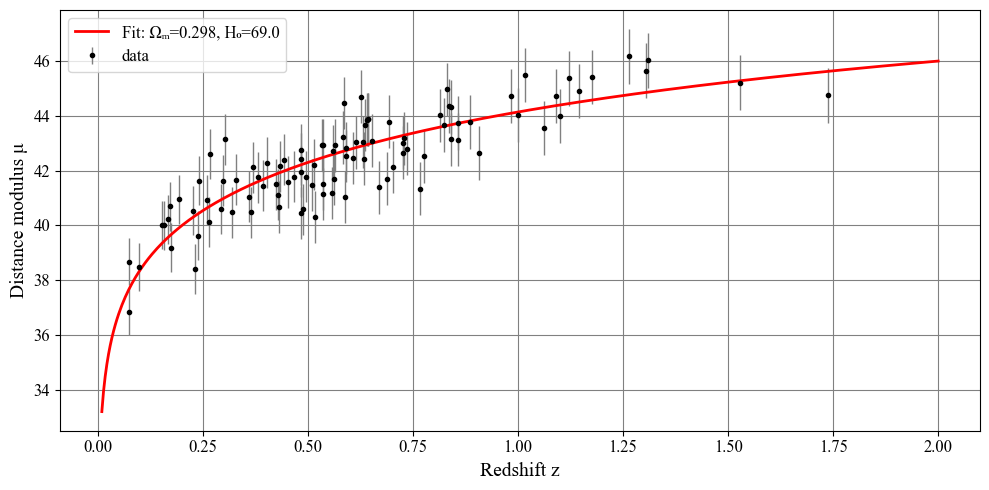

In [112]:
# Plot
z_plot = np.linspace(0.01, 2, 500)
mu_fit = mu_theory(z_plot, Omega_m_fit, H0_fit)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_plot, mu_fit, label=f"Fit: Ωₘ={Omega_m_fit:.3f}, H₀={H0_fit:.1f}", lw=2, color='red')
plt.xlabel("Redshift z")
plt.ylabel("Distance modulus μ")
plt.legend()
plt.show()